In [15]:
# Importing Required Libraries

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree

In [16]:
# Creating Dataset

data = pd.DataFrame({
    'Size': [10, 12, 11, 15, 14, 13, 30, 32, 35, 31, 34, 33],
    'Weight': [100, 120, 110, 150, 140, 130,
               300, 320, 350, 310, 340, 330],
    'Sweetness': [8, 9, 8, 7, 8, 9,
                  5, 4, 5, 4, 5, 4],
    'Class': ['Class-A', 'Class-A', 'Class-A',
              'Class-A', 'Class-A', 'Class-A',
              'Class-B', 'Class-B', 'Class-B',
              'Class-B', 'Class-B', 'Class-B']
})

print(data.shape)
print(data.head())

(12, 4)
   Size  Weight  Sweetness    Class
0    10     100          8  Class-A
1    12     120          9  Class-A
2    11     110          8  Class-A
3    15     150          7  Class-A
4    14     140          8  Class-A


In [17]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [18]:
# Splitting the dataset into Training and Testing Dataset

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=41
)

In [19]:
# Preprocessing Data with StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [20]:
# Fitting the Model Random Forest Classifier

model = RandomForestClassifier(
    n_estimators=5,
    criterion='entropy',
    random_state=0
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [21]:
# Evaluation Metrics

print('Random Forest Classifier')

conf_mat = confusion_matrix(y_test, y_pred)

print('\nConfusion Matrix :\n', conf_mat)

accuracy_score = accuracy_score(y_test, y_pred)

print('Accuracy Score : ', accuracy_score)

print('Accuracy in Percentage : ',
      int(accuracy_score * 100), '%')

print('\n', classification_report(y_test, y_pred))

Random Forest Classifier

Confusion Matrix :
 [[1 0]
 [0 2]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %

               precision    recall  f1-score   support

     Class-A       1.00      1.00      1.00         1
     Class-B       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [22]:
# Predicting a new fruit

new_fruit = [[13, 125, 8]]

new_fruit = sc.transform(new_fruit)

prediction = model.predict(new_fruit)

print("Predicted Class :", prediction[0])

Predicted Class : Class-A


In [23]:
# Majority Voting of Individual Decision Trees

tree_predictions = []

for i, estimator in enumerate(model.estimators_, 1):

    prediction = estimator.predict(new_fruit)[0]

    tree_predictions.append(prediction)

    print("Tree", i, "Prediction :", prediction)

Tree 1 Prediction : 0.0
Tree 2 Prediction : 0.0
Tree 3 Prediction : 0.0
Tree 4 Prediction : 0.0
Tree 5 Prediction : 0.0


In [24]:
# Majority Voting

from collections import Counter

vote_count = Counter(tree_predictions)

final_class = vote_count.most_common(1)[0][0]

print("\nMajority Voting")

print("Class-A Votes :", vote_count['Class-A'])

print("Class-B Votes :", vote_count['Class-B'])

print("\nFinal Class :", final_class)


Majority Voting
Class-A Votes : 0
Class-B Votes : 0

Final Class : 0.0


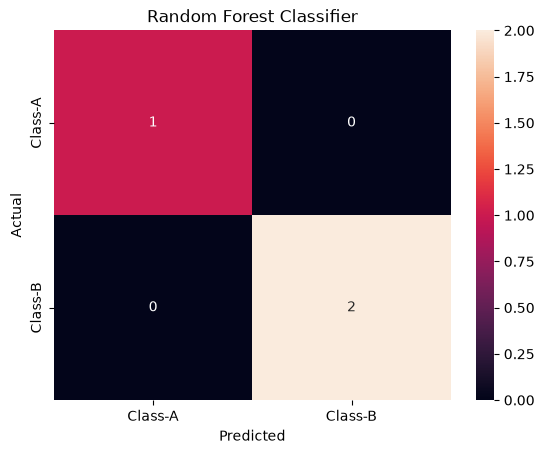

In [25]:
# Visualizing Confusion Matrix

conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(
    title='Random Forest Classifier'
)

plt.show()

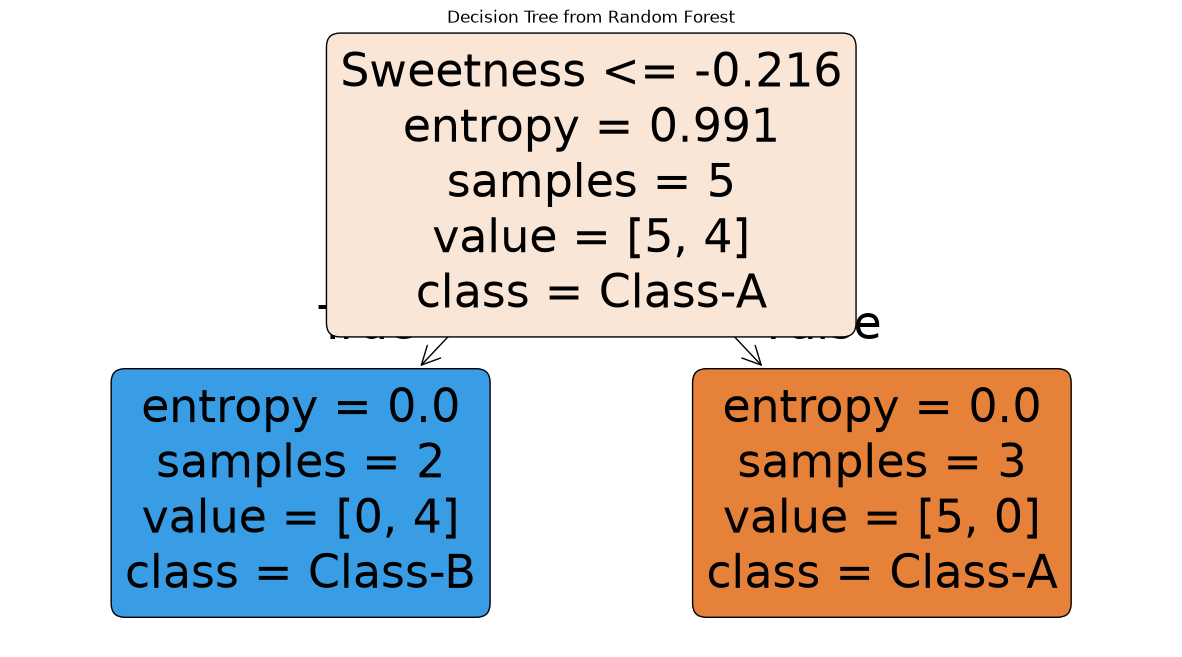

In [31]:
# Visualizing Tree formed

plt.figure(figsize=(15, 8))

tree.plot_tree(
    model.estimators_[0],
    feature_names=data.columns[:-1],
    class_names=['Class-A', 'Class-B'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree from Random Forest")

plt.show()